In [1]:
import os
import h5py
import numpy
import scipy
from matplotlib import pyplot

In [2]:
# Tag
tag='Y1'
folder="/global/cfs/cdirs/lsst/groups/MCP/CosmoCloud/ZCloud/"

In [3]:
# Path
model_folder = os.path.join(folder, 'MODEL/')
dataset_folder = os.path.join(folder, 'DATASET/')
ensemble_folder = os.path.join(folder, 'ENSEMBLE/')
notebook_folder = os.path.join(folder, 'NOTEBOOK/')
summarize_folder = os.path.join(folder, 'SUMMARIZE/')

In [4]:
# Configuration
os.environ['PATH'] = '/global/homes/y/yhzhang/opt/texlive/bin/x86_64-linux:' + os.environ['PATH']
pyplot.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
pyplot.rcParams['pgf.texsystem'] = 'pdflatex'
pyplot.rcParams['text.usetex'] = True
pyplot.rcParams['font.size'] = 20

In [5]:
# Summarize Lens
with h5py.File(os.path.join(ensemble_folder, '{}/LENS/SOM.hdf5'.format(tag)), 'r') as file:
    som_average_lens = file['average'][...]

with h5py.File(os.path.join(ensemble_folder, '{}/LENS/MODEL.hdf5'.format(tag)), 'r') as file:
    model_average_lens = file['average'][...]

with h5py.File(os.path.join(ensemble_folder, '{}/LENS/PRODUCT.hdf5'.format(tag)), 'r') as file:
    product_average_lens = file['average'][...]

with h5py.File(os.path.join(ensemble_folder, '{}/LENS/HISTOGRAM.hdf5'.format(tag)), 'r') as file:
    histogram_average_lens = file['average'][...]

# Summarize Source
with h5py.File(os.path.join(ensemble_folder, '{}/SOURCE/SOM.hdf5'.format(tag)), 'r') as file:
    som_average_source = file['average'][...]

with h5py.File(os.path.join(ensemble_folder, '{}/SOURCE/MODEL.hdf5'.format(tag)), 'r') as file:
    model_average_source = file['average'][...]

with h5py.File(os.path.join(ensemble_folder, '{}/SOURCE/PRODUCT.hdf5'.format(tag)), 'r') as file:
    product_average_source = file['average'][...]

with h5py.File(os.path.join(ensemble_folder, '{}/SOURCE/HISTOGRAM.hdf5'.format(tag)), 'r') as file:
    histogram_average_source = file['average'][...]

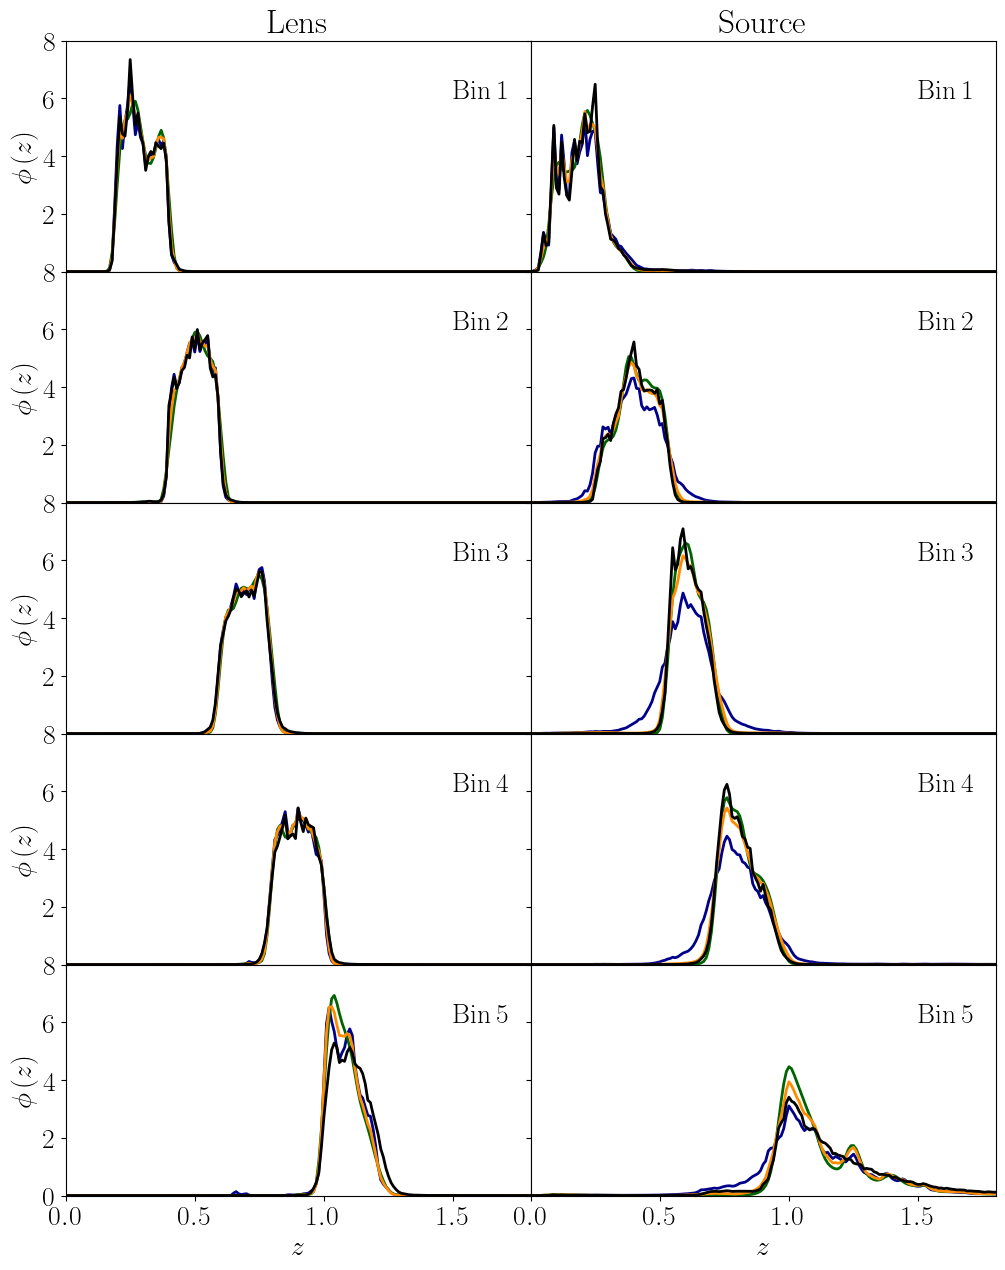

In [6]:
# Redshift
z1 = 0.0
z2 = 3.0
grid_size = 300
z_grid = numpy.linspace(z1, z2, grid_size + 1)

# Plot
bin_size = 5
figure, plot = pyplot.subplots(nrows=bin_size, ncols=2, figsize=(12, 3 * bin_size))

for m in range(bin_size):
    plot[m, 0].plot(z_grid, som_average_lens[m, :], color='darkblue', linewidth=2.0, linestyle='-')
    
    plot[m, 0].plot(z_grid, model_average_lens[m, :], color='darkgreen', linewidth=2.0, linestyle='-')
    
    plot[m, 0].plot(z_grid, product_average_lens[m, :], color='darkorange', linewidth=2.0, linestyle='-')
    
    plot[m, 0].plot(z_grid, histogram_average_lens[m, :], color='black', linewidth=2.0, linestyle='-')
    
    plot[m, 0].set_ylim(0, 8)
    plot[m, 0].set_xlim(0.0, 1.8)
    
    plot[m, 0].set_ylabel(r'$\phi \left( z \right)$')
    plot[m, 0].text(x=1.5, y=6.0, s=r'$\mathrm{Bin} \, ' + r'{}$'.format(m + 1), fontsize=20)
    
    if m == 0:
        plot[m, 0].set_title(r'$\mathrm{Lens}$')
    
    if m < bin_size - 1:
        plot[m, 0].set_xticklabels([])
        plot[m, 0].set_yticks([2.0, 4.0, 6.0, 8.0])
    else:
        plot[m, 0].set_xlabel(r'$z$')

for m in range(bin_size):
    plot[m, 1].plot(z_grid, som_average_source[m, :], color='darkblue', linewidth=2.0, linestyle='-')
    
    plot[m, 1].plot(z_grid, model_average_source[m, :], color='darkgreen', linewidth=2.0, linestyle='-')
    
    plot[m, 1].plot(z_grid, product_average_source[m, :], color='darkorange', linewidth=2.0, linestyle='-')
    
    plot[m, 1].plot(z_grid, histogram_average_source[m, :], color='black', linewidth=2.0, linestyle='-')
    
    plot[m, 1].set_ylim(0, 8)
    plot[m, 1].set_xlim(0.0, 1.8)
    
    plot[m, 1].set_yticklabels([])
    plot[m, 1].text(x=1.5, y=6.0, s=r'$\mathrm{Bin} \, ' + r'{}$'.format(m + 1), fontsize=20)
    
    if m == 0:
        plot[m, 1].set_title(r'$\mathrm{Source}$')
    
    if m < bin_size - 1:
        plot[m, 1].set_xticklabels([])
    else:
        plot[m, 1].set_xlabel(r'$z$')

os.makedirs(notebook_folder, exist_ok=True)
os.makedirs(os.path.join(notebook_folder, '{}/AVERAGE/'.format(tag)), exist_ok=True)

figure.subplots_adjust(wspace=0.0, hspace=0.0)
figure.savefig(os.path.join(notebook_folder, '{}/AVERAGE/FIGURE.png'.format(tag)), bbox_inches='tight', format='png', dpi=512)

In [7]:
# Summarize Lens
with h5py.File(os.path.join(ensemble_folder, '{}/LENS/SOM.hdf5'.format(tag)), 'r') as file:
    som_data_lens = file['data'][...]

with h5py.File(os.path.join(ensemble_folder, '{}/LENS/MODEL.hdf5'.format(tag)), 'r') as file:
    model_data_lens = file['data'][...]

with h5py.File(os.path.join(ensemble_folder, '{}/LENS/PRODUCT.hdf5'.format(tag)), 'r') as file:
    product_data_lens = file['data'][...]

with h5py.File(os.path.join(ensemble_folder, '{}/LENS/HISTOGRAM.hdf5'.format(tag)), 'r') as file:
    histogram_data_lens = file['data'][...]

# Summarize Source
with h5py.File(os.path.join(ensemble_folder, '{}/SOURCE/SOM.hdf5'.format(tag)), 'r') as file:
    som_data_source = file['data'][...]

with h5py.File(os.path.join(ensemble_folder, '{}/SOURCE/MODEL.hdf5'.format(tag)), 'r') as file:
    model_data_source = file['data'][...]

with h5py.File(os.path.join(ensemble_folder, '{}/SOURCE/PRODUCT.hdf5'.format(tag)), 'r') as file:
    product_data_source = file['data'][...]

with h5py.File(os.path.join(ensemble_folder, '{}/SOURCE/HISTOGRAM.hdf5'.format(tag)), 'r') as file:
    histogram_data_source = file['data'][...]

# Redshift
z1 = 0.0
z2 = 3.0
grid_size = 300
z_grid = numpy.linspace(z1, z2, grid_size + 1)

# Mean
som_mean_lens = scipy.integrate.trapezoid(x=z_grid, y=z_grid[numpy.newaxis, numpy.newaxis, :] * som_data_lens, axis=2)
model_mean_lens = scipy.integrate.trapezoid(x=z_grid, y=z_grid[numpy.newaxis, numpy.newaxis, :] * model_data_lens, axis=2)
product_mean_lens = scipy.integrate.trapezoid(x=z_grid, y=z_grid[numpy.newaxis, numpy.newaxis, :] * product_data_lens, axis=2)
histogram_mean_lens = scipy.integrate.trapezoid(x=z_grid, y=z_grid[numpy.newaxis, numpy.newaxis, :] * histogram_data_lens, axis=2)

som_mean_source = scipy.integrate.trapezoid(x=z_grid, y=z_grid[numpy.newaxis, numpy.newaxis, :] * som_data_source, axis=2)
model_mean_source = scipy.integrate.trapezoid(x=z_grid, y=z_grid[numpy.newaxis, numpy.newaxis, :] * model_data_source, axis=2)
product_mean_source = scipy.integrate.trapezoid(x=z_grid, y=z_grid[numpy.newaxis, numpy.newaxis, :] * product_data_source, axis=2)
histogram_mean_source = scipy.integrate.trapezoid(x=z_grid, y=z_grid[numpy.newaxis, numpy.newaxis, :] * histogram_data_source, axis=2)

# Center
som_center_lens = numpy.mean(som_mean_lens, axis=0)
model_center_lens = numpy.mean(model_mean_lens, axis=0)
product_center_lens = numpy.mean(product_mean_lens, axis=0)
histogram_center_lens = numpy.mean(histogram_mean_lens, axis=0)

som_center_source = numpy.mean(som_mean_source, axis=0)
model_center_source = numpy.mean(model_mean_source, axis=0)
product_center_source = numpy.mean(product_mean_source, axis=0)
histogram_center_source = numpy.mean(histogram_mean_source, axis=0)

# Delta
som_delta_lens = numpy.abs(som_center_lens - histogram_center_lens) / (1 + histogram_center_lens)
model_delta_lens = numpy.abs(model_center_lens - histogram_center_lens) / (1 + histogram_center_lens)
product_delta_lens = numpy.abs(product_center_lens - histogram_center_lens) / (1 + histogram_center_lens)

som_delta_source = numpy.abs(som_center_source - histogram_center_source) / (1 + histogram_center_source)
model_delta_source = numpy.abs(model_center_source - histogram_center_source) / (1 + histogram_center_source)
product_delta_source = numpy.abs(product_center_source - histogram_center_source) / (1 + histogram_center_source)

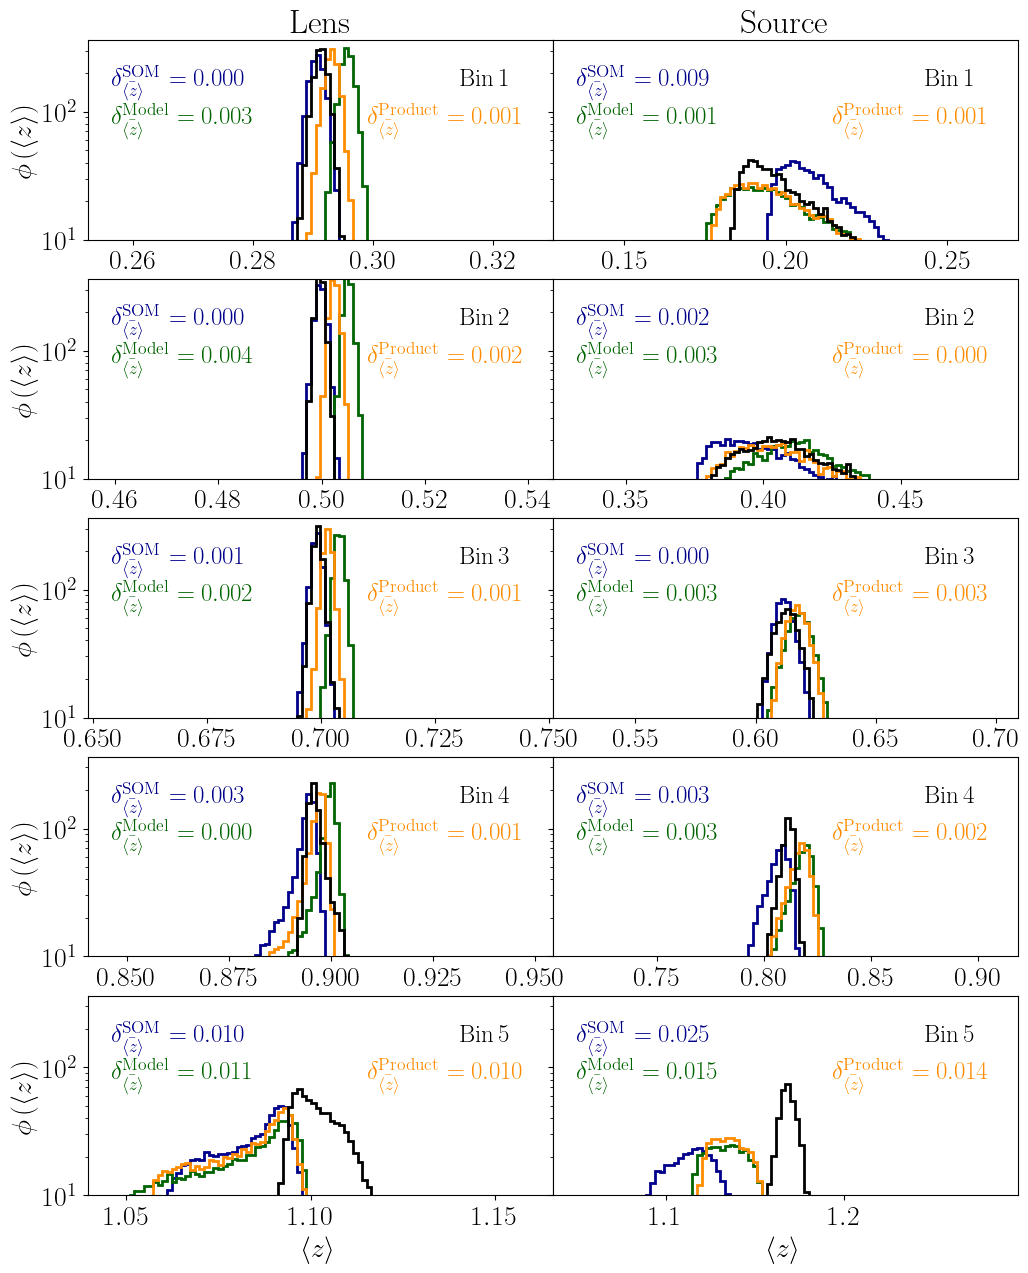

In [8]:
# Plot
size = 100
bin_size = 5
lens_range = 0.03 * (1 + histogram_center_lens)
source_range = 0.06 * (1 + histogram_center_source)
figure, plot = pyplot.subplots(nrows=bin_size, ncols=2, figsize=(12, 3 * bin_size))

for m in range(bin_size):
    
    plot[m, 0].hist(som_mean_lens[:, m], bins=size, range=(histogram_center_lens[m] - lens_range[m], histogram_center_lens[m] + lens_range[m]), color='darkblue', density=True, histtype='step', linewidth=2.0, linestyle='-')
    
    plot[m, 0].hist(model_mean_lens[:, m], bins=size, range=(histogram_center_lens[m] - lens_range[m], histogram_center_lens[m] + lens_range[m]), color='darkgreen', density=True, histtype='step', linewidth=2.0, linestyle='-')
    
    plot[m, 0].hist(product_mean_lens[:, m], bins=size, range=(histogram_center_lens[m] - lens_range[m], histogram_center_lens[m] + lens_range[m]), color='darkorange', density=True, histtype='step', linewidth=2.0, linestyle='-')
    
    plot[m, 0].hist(histogram_mean_lens[:, m], bins=size, range=(histogram_center_lens[m] - lens_range[m], histogram_center_lens[m] + lens_range[m]), color='black', density=True, histtype='step', linewidth=2.0, linestyle='-')
    
    plot[m, 0].text(x=histogram_center_lens[m] + lens_range[m] * 0.6, y=160, s=r'$\mathrm{Bin} \, ' + r'{}$'.format(m + 1), fontsize=18)
    
    plot[m, 0].text(x=histogram_center_lens[m] - lens_range[m] * 0.9, y=160, s=r'$\delta^\mathrm{SOM}_{\bar{\langle z \rangle}} = ' + r'{:.3f}$'.format(som_delta_lens[m]), fontsize=18, color='darkblue')
    
    plot[m, 0].text(x=histogram_center_lens[m] - lens_range[m] * 0.9, y=80, s=r'$\delta^\mathrm{Model}_{\bar{\langle z \rangle}} = ' + r'{:.3f}$'.format(model_delta_lens[m]), fontsize=18, color='darkgreen')
    
    plot[m, 0].text(x=histogram_center_lens[m] + lens_range[m] * 0.2, y=80, s=r'$\delta^\mathrm{Product}_{\bar{\langle z \rangle}} = ' + r'{:.3f}$'.format(product_delta_lens[m]), fontsize=18, color='darkorange')
    
    plot[m, 0].set_ylim(10, 360)
    plot[m, 0].set_xlim(histogram_center_lens[m] - lens_range[m], histogram_center_lens[m] + lens_range[m])
    
    plot[m, 0].set_yscale('log')
    plot[m, 0].set_ylabel(r'$\phi \left( \langle z \rangle \right)$')
    
    if m == 0:
        plot[m, 0].set_title(r'$\mathrm{Lens}$')
    
    if m == bin_size - 1:
        plot[m, 0].set_xlabel(r'$\langle z \rangle$')


for m in range(bin_size):
    plot[m, 1].hist(som_mean_source[:, m], bins=size, range=(histogram_center_source[m] - source_range[m], histogram_center_source[m] + source_range[m]), color='darkblue', density=True, histtype='step', linewidth=2.0, linestyle='-')
    
    plot[m, 1].hist(model_mean_source[:, m], bins=size, range=(histogram_center_source[m] - source_range[m], histogram_center_source[m] + source_range[m]), color='darkgreen', density=True, histtype='step', linewidth=2.0, linestyle='-')
    
    plot[m, 1].hist(product_mean_source[:, m], bins=size, range=(histogram_center_source[m] - source_range[m], histogram_center_source[m] + source_range[m]), color='darkorange', density=True, histtype='step', linewidth=2.0, linestyle='-')
    
    plot[m, 1].hist(histogram_mean_source[:, m], bins=size, range=(histogram_center_source[m] - source_range[m], histogram_center_source[m] + source_range[m]), color='black', density=True, histtype='step', linewidth=2.0, linestyle='-')
    
    plot[m, 1].text(x=histogram_center_source[m] + source_range[m] * 0.6, y=160, s=r'$\mathrm{Bin} \, ' + r'{}$'.format(m + 1), fontsize=18)
    
    plot[m, 1].text(x=histogram_center_source[m] - source_range[m] * 0.9, y=160, s=r'$\delta^\mathrm{SOM}_{\bar{\langle z \rangle}} = ' + r'{:.3f}$'.format(som_delta_source[m]), fontsize=18, color='darkblue')
    
    plot[m, 1].text(x=histogram_center_source[m] - source_range[m] * 0.9, y=80, s=r'$\delta^\mathrm{Model}_{\bar{\langle z \rangle}} = ' + r'{:.3f}$'.format(model_delta_source[m]), fontsize=18, color='darkgreen')
    
    plot[m, 1].text(x=histogram_center_source[m] + source_range[m] * 0.2, y=80, s=r'$\delta^\mathrm{Product}_{\bar{\langle z \rangle}} = ' + r'{:.3f}$'.format(product_delta_source[m]), fontsize=18, color='darkorange')
    
    plot[m, 1].set_ylim(10, 360)
    plot[m, 1].set_xlim(histogram_center_source[m] - source_range[m], histogram_center_source[m] + source_range[m])
    
    plot[m, 1].set_yscale('log')
    plot[m, 1].set_yticklabels([])
    
    if m == 0:
        plot[m, 1].set_title(r'$\mathrm{Source}$')
    
    if m == bin_size - 1:
        plot[m, 1].set_xlabel(r'$\langle z \rangle$')

os.makedirs(notebook_folder, exist_ok=True)
os.makedirs(os.path.join(notebook_folder, '{}/DELTA/'.format(tag)), exist_ok=True)

figure.subplots_adjust(wspace=0.00, hspace=0.2)
figure.savefig(os.path.join(notebook_folder, '{}/DELTA/FIGURE.png'.format(tag)), bbox_inches='tight', format='png', dpi=512)

In [9]:
# Redshift
z1 = 0.0
z2 = 3.0
grid_size = 300
z_grid = numpy.linspace(z1, z2, grid_size + 1)

# Bin
with h5py.File(os.path.join(model_folder, '{}/SELECT/DATA0.hdf5'.format(tag)), 'r') as file:
    bin_lens_size = len(file['bin_lens'][...]) - 1
    bin_source_size = len(file['bin_source'][...]) - 1

# Definition
plot_size = 10000
ensemble_size = 500000
indices = numpy.sort(numpy.random.choice(ensemble_size, plot_size, replace=False))

lens_color_list = ['darkmagenta', 'darkblue', 'darkgreen', 'darkorange', 'darkred']
source_color_list = ['darkmagenta', 'darkblue', 'darkgreen', 'darkorange', 'darkred']

# Select Lens
som_select_lens = som_data_lens[indices, :, :]
model_select_lens = model_data_lens[indices, :, :]
product_select_lens = product_data_lens[indices, :, :]
histogram_select_lens = histogram_data_lens[indices, :, :]

# Select Source
som_select_source = som_data_source[indices, :, :]
model_select_source = model_data_source[indices, :, :]
product_select_source = product_data_source[indices, :, :]
histogram_select_source = histogram_data_source[indices, :, :]

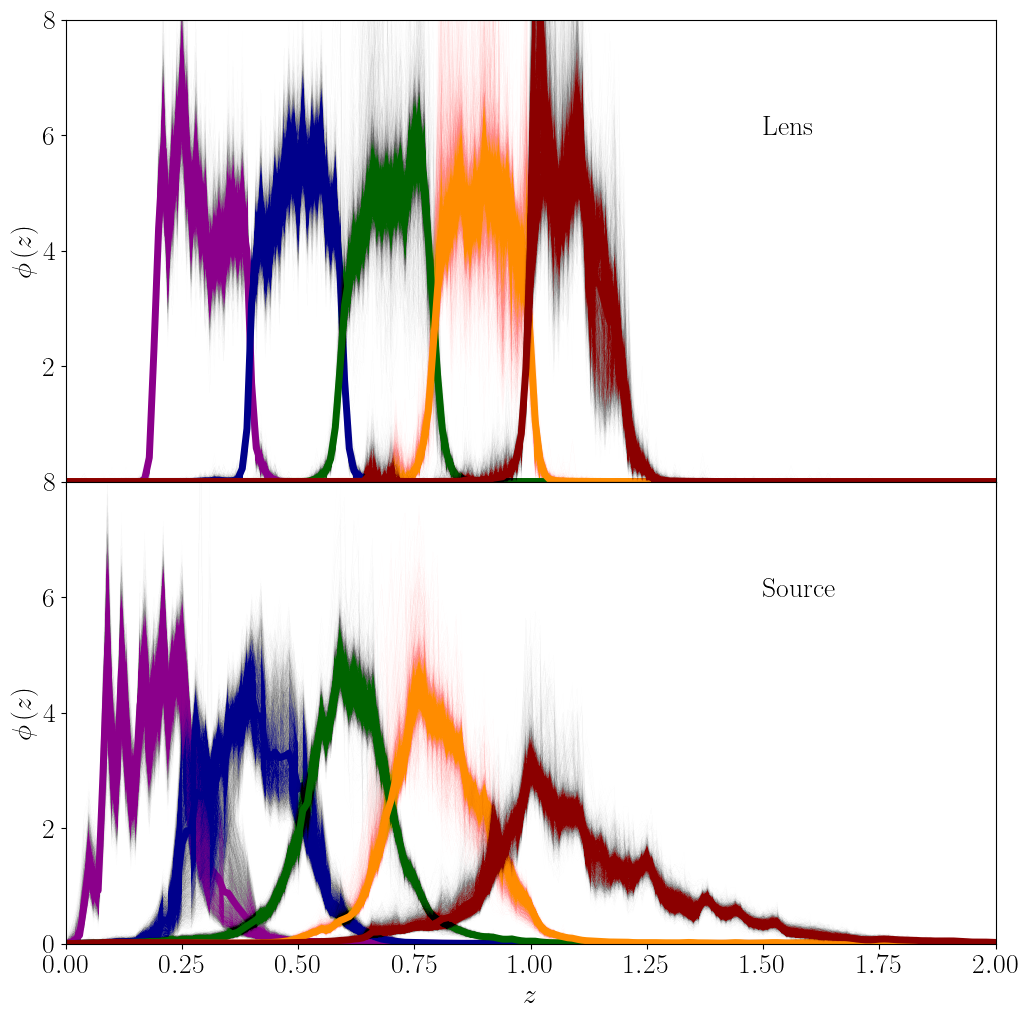

In [10]:
# SOM
figure, plot = pyplot.subplots(nrows = 2, ncols = 1, figsize = (12, 12))

for m in range(bin_lens_size):
    
    plot[0].plot(z_grid, numpy.transpose(som_select_lens[:, m, :]), color = lens_color_list[m], linewidth = 0.04, alpha = 0.04)
    
    plot[0].plot(z_grid, numpy.mean(som_select_lens[:, m, :], axis=0), color = lens_color_list[m], linewidth = 5.0, label=r'$m = {:.0f}$'.format(m + 1))

plot[0].set_xlim(0.0, 2.0)
plot[0].set_ylim(0.0, 8.0)

plot[0].set_xticklabels([])
plot[0].set_yticks([2.0, 4.0, 6.0, 8.0])

plot[0].set_ylabel(r'$\phi \left( z \right)$')
plot[0].text(x=1.5, y=6.0, s=r'$\mathrm{Lens}$', fontsize=20)

for m in range(bin_source_size):
    
    plot[1].plot(z_grid, numpy.transpose(som_select_source[:, m, :]), color = source_color_list[m], linewidth = 0.04, alpha = 0.04)
    
    plot[1].plot(z_grid, numpy.mean(som_select_source[:, m, :], axis=0), color = source_color_list[m], linewidth = 5.0)

plot[1].set_xlim(0.0, 2.0)
plot[1].set_ylim(0.0, 8.0)
plot[1].set_yticks([0.0, 2.0, 4.0, 6.0, 8.0])

plot[1].set_xlabel(r'$z$')
plot[1].set_ylabel(r'$\phi \left( z \right)$')
plot[1].text(x=1.5, y=6.0, s=r'$\mathrm{Source}$', fontsize=20)

os.makedirs(notebook_folder, exist_ok=True)
os.makedirs(os.path.join(notebook_folder, '{}/ENSEMBLE/'.format(tag)), exist_ok=True)

figure.subplots_adjust(hspace=0.0)
figure.savefig(os.path.join(notebook_folder, '{}/ENSEMBLE/FIGURE_SOM.png'.format(tag)), bbox_inches='tight', format='png', dpi=512)

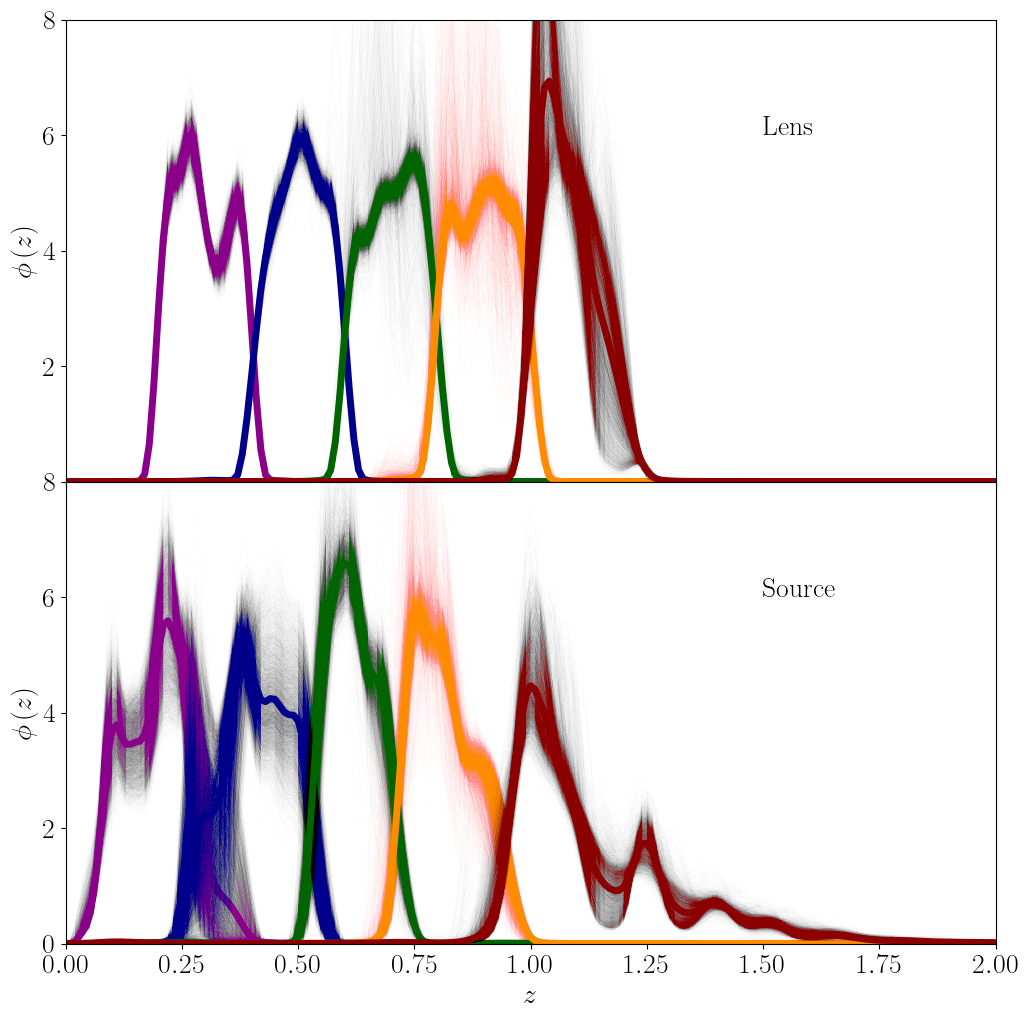

In [11]:
# Model
figure, plot = pyplot.subplots(nrows = 2, ncols = 1, figsize = (12, 12))

for m in range(bin_lens_size):
    
    plot[0].plot(z_grid, numpy.transpose(model_select_lens[:, m, :]), color = lens_color_list[m], linewidth = 0.04, alpha = 0.04)
    
    plot[0].plot(z_grid, numpy.mean(model_select_lens[:, m, :], axis=0), color = lens_color_list[m], linewidth = 5.0, label=r'$m = {:.0f}$'.format(m + 1))

plot[0].set_xlim(0.0, 2.0)
plot[0].set_ylim(0.0, 8.0)

plot[0].set_xticklabels([])
plot[0].set_yticks([2.0, 4.0, 6.0, 8.0])

plot[0].set_ylabel(r'$\phi \left( z \right)$')
plot[0].text(x=1.5, y=6.0, s=r'$\mathrm{Lens}$', fontsize=20)

for m in range(bin_source_size):
    
    plot[1].plot(z_grid, numpy.transpose(model_select_source[:, m, :]), color = source_color_list[m], linewidth = 0.04, alpha = 0.04)
    
    plot[1].plot(z_grid, numpy.mean(model_select_source[:, m, :], axis=0), color = source_color_list[m], linewidth = 5.0)

plot[1].set_xlim(0.0, 2.0)
plot[1].set_ylim(0.0, 8.0)
plot[1].set_yticks([0.0, 2.0, 4.0, 6.0, 8.0])

plot[1].set_xlabel(r'$z$')
plot[1].set_ylabel(r'$\phi \left( z \right)$')
plot[1].text(x=1.5, y=6.0, s=r'$\mathrm{Source}$', fontsize=20)

os.makedirs(notebook_folder, exist_ok=True)
os.makedirs(os.path.join(notebook_folder, '{}/ENSEMBLE/'.format(tag)), exist_ok=True)

figure.subplots_adjust(hspace=0.0)
figure.savefig(os.path.join(notebook_folder, '{}/ENSEMBLE/FIGURE_MODEL.png'.format(tag)), bbox_inches='tight', format='png', dpi=512)

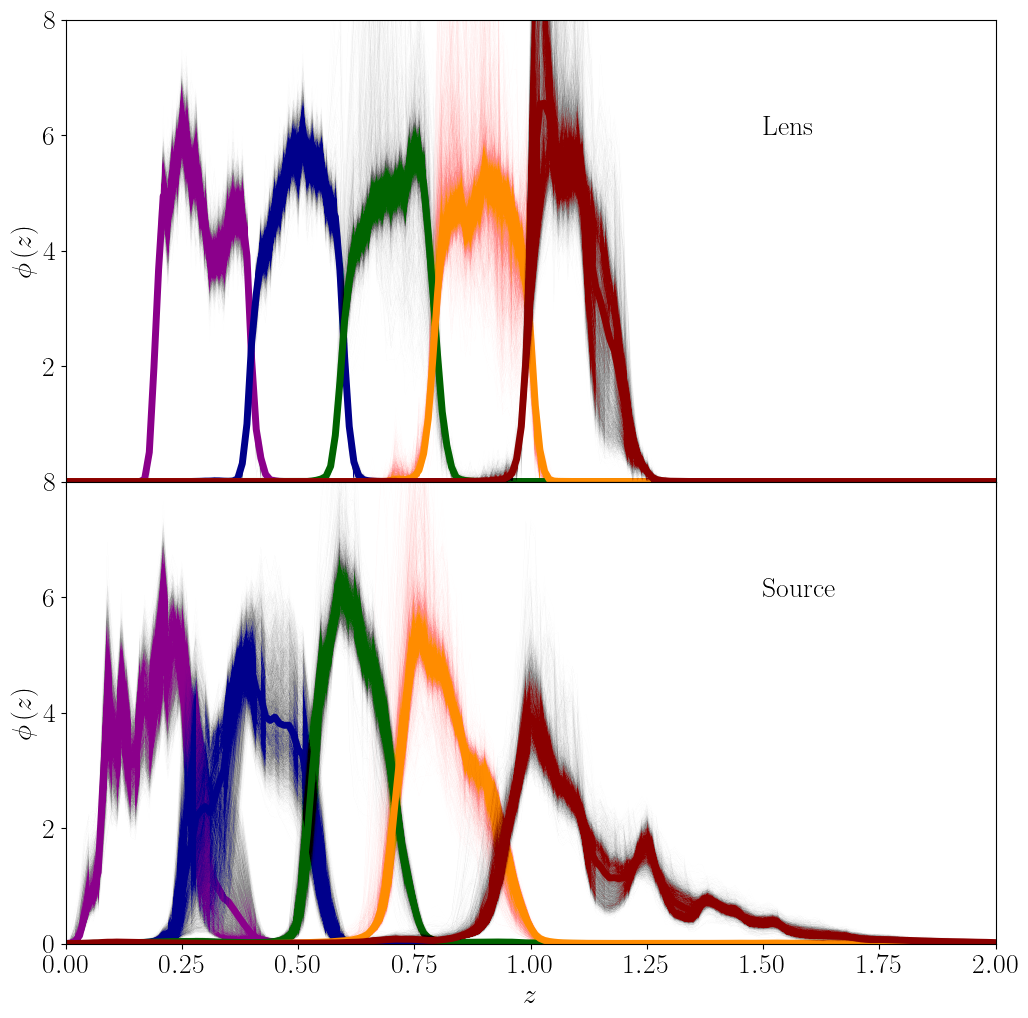

In [12]:
# Product
figure, plot = pyplot.subplots(nrows = 2, ncols = 1, figsize = (12, 12))

for m in range(bin_lens_size):
    
    plot[0].plot(z_grid, numpy.transpose(product_select_lens[:, m, :]), color = lens_color_list[m], linewidth = 0.04, alpha = 0.04)
    
    plot[0].plot(z_grid, numpy.mean(product_select_lens[:, m, :], axis=0), color = lens_color_list[m], linewidth = 5.0, label=r'$m = {:.0f}$'.format(m + 1))

plot[0].set_xlim(0.0, 2.0)
plot[0].set_ylim(0.0, 8.0)
plot[1].set_yticks([0.0, 2.0, 4.0, 6.0, 8.0])

plot[0].set_xticklabels([])
plot[0].set_yticks([2.0, 4.0, 6.0, 8.0])

plot[0].set_ylabel(r'$\phi \left( z \right)$')
plot[0].text(x=1.5, y=6.0, s=r'$\mathrm{Lens}$', fontsize=20)

for m in range(bin_source_size):
    
    plot[1].plot(z_grid, numpy.transpose(product_select_source[:, m, :]), color = source_color_list[m], linewidth = 0.04, alpha = 0.04)
    
    plot[1].plot(z_grid, numpy.mean(product_select_source[:, m, :], axis=0), color = source_color_list[m], linewidth = 5.0)

plot[1].set_xlim(0.0, 2.0)
plot[1].set_ylim(0.0, 8.0)

plot[1].set_xlabel(r'$z$')
plot[1].set_ylabel(r'$\phi \left( z \right)$')
plot[1].text(x=1.5, y=6.0, s=r'$\mathrm{Source}$', fontsize=20)

os.makedirs(notebook_folder, exist_ok=True)
os.makedirs(os.path.join(notebook_folder, '{}/ENSEMBLE/'.format(tag)), exist_ok=True)

figure.subplots_adjust(hspace=0.0)
figure.savefig(os.path.join(notebook_folder, '{}/ENSEMBLE/FIGURE_PRODUCT.png'.format(tag)), bbox_inches='tight', format='png', dpi=512)

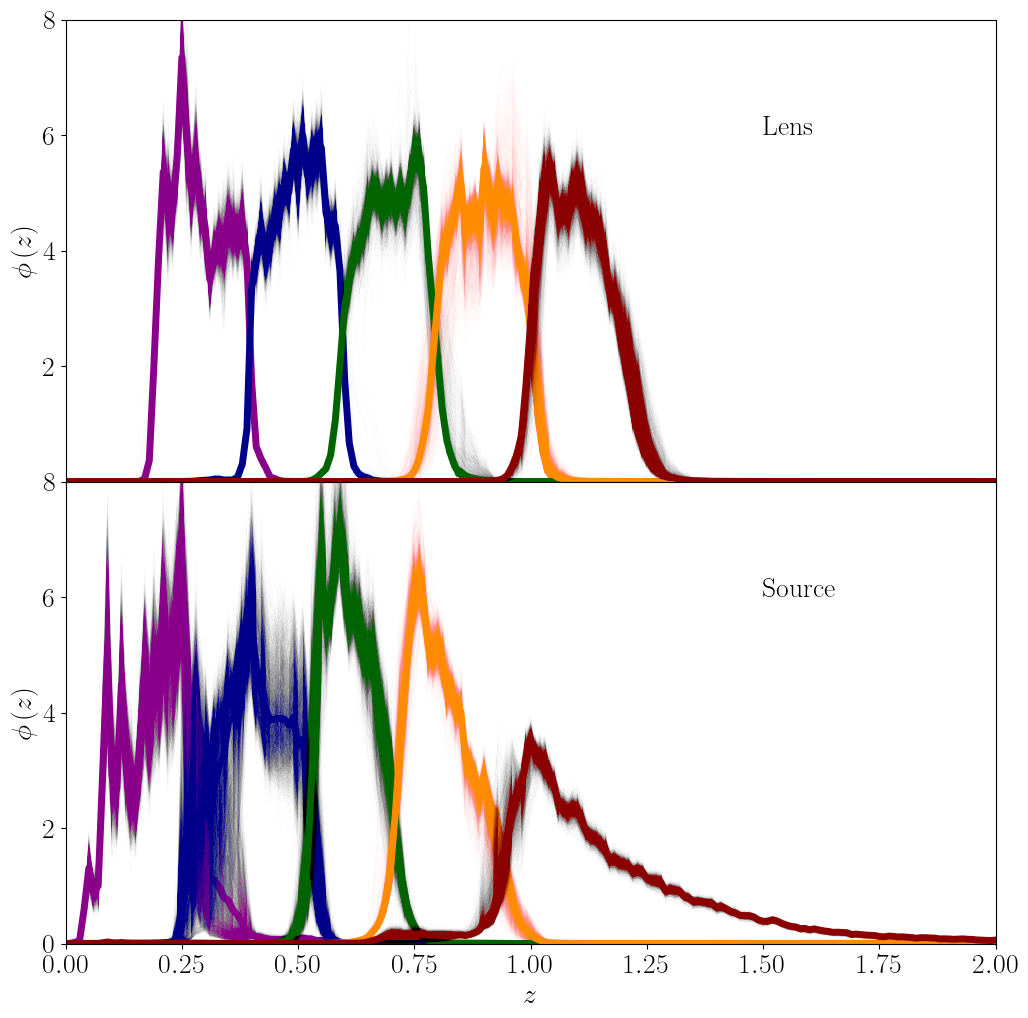

In [13]:
# Histogram
figure, plot = pyplot.subplots(nrows = 2, ncols = 1, figsize = (12, 12))

for m in range(bin_lens_size):
    
    plot[0].plot(z_grid, numpy.transpose(histogram_select_lens[:, m, :]), color = lens_color_list[m], linewidth = 0.04, alpha = 0.04)
    
    plot[0].plot(z_grid, numpy.mean(histogram_select_lens[:, m, :], axis=0), color = lens_color_list[m], linewidth = 5.0, label=r'$m = {:.0f}$'.format(m + 1))

plot[0].set_xlim(0.0, 2.0)
plot[0].set_ylim(0.0, 8.0)

plot[0].set_xticklabels([])
plot[0].set_yticks([2.0, 4.0, 6.0, 8.0])

plot[0].set_ylabel(r'$\phi \left( z \right)$')
plot[0].text(x=1.5, y=6.0, s=r'$\mathrm{Lens}$', fontsize=20)

for m in range(bin_source_size):
    
    plot[1].plot(z_grid, numpy.transpose(histogram_select_source[:, m, :]), color = source_color_list[m], linewidth = 0.04, alpha = 0.04)
    
    plot[1].plot(z_grid, numpy.mean(histogram_select_source[:, m, :], axis=0), color = source_color_list[m], linewidth = 5.0)

plot[1].set_xlim(0.0, 2.0)
plot[1].set_ylim(0.0, 8.0)
plot[1].set_yticks([0.0, 2.0, 4.0, 6.0, 8.0])

plot[1].set_xlabel(r'$z$')
plot[1].set_ylabel(r'$\phi \left( z \right)$')
plot[1].text(x=1.5, y=6.0, s=r'$\mathrm{Source}$', fontsize=20)

os.makedirs(notebook_folder, exist_ok=True)
os.makedirs(os.path.join(notebook_folder, '{}/ENSEMBLE/'.format(tag)), exist_ok=True)

figure.subplots_adjust(hspace=0.0)
figure.savefig(os.path.join(notebook_folder, '{}/ENSEMBLE/FIGURE_HISTOGRAM.png'.format(tag)), bbox_inches='tight', format='png', dpi=512)